<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week05/NN_libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to the deep-learning libraries in Python on a simple example (Breast Cancer Dataset)
- The goal of the following examples is not to learn all frameworks in detail.
- They illustrate different programming styles used in modern deep learning frameworks.
- For this course we will primarily use **Keras**.



### Deep Learning Libraries:

- **TensorFlow, PyTorch, Jax**: Low-level deep learning frameworks for defining and optimizing neural networks.
- **Keras**: High-level API that simplifies deep learning model creation, primarily built on TensorFlow (but can also work with other backends).
- **Lightning**: High-level API built on PyTorch, providing structured training loops and scalability.


### Machine Learning Workflow
1. Process the data
  - 1. Load, observe and analyze the data
  - 2. Clean and preprocess the data
2. Define the model
  - 1. Define the model architecture (type of the model, number of layers, activation functions)
  - 2. Set model hyperparameters (learning rate, batch size, optimizer, loss function,...)
3. Train the model
4. Evaluate the model and make predictions
   - 1. Assess model performance on training, validation and test data
   - 2. Use the trained model to predict on new unseen data

## 1. Process the data
1. Load and analyze the data
 - load the Breat Cancer Dataset (https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic, https://scikit-learn.org/stable/api/sklearn.datasets.html, https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)
    - a nice dataset of 569 samples and 30 input features (real, positive) and one output featue



In [1]:
from sklearn.datasets import load_breast_cancer
import numpy as np

# Load and observe the data:
cancer = load_breast_cancer()  # dict
print(cancer.keys())

# Observe shape:
print("Input data shape:", cancer['data'].shape)
print("Target data shape:", cancer['target'].shape, "\n")

# Analyze the label distribution:
print("Target names:", cancer['target_names'])
print("Target distribution:", np.bincount(cancer['target']), "\n")

# Observe input data:
print("Feature names:", cancer['feature_names'] )
print("Minimum, mean and maximum input data values: ", np.min(cancer['data']), np.mean(cancer['data']), np.max(cancer['data']))
#print("Feature means:", np.mean(cancer['data'], axis=0))
#print("Feature description:", cancer['DESCR'])  # description of the data
print()

# Check for missing values
print("Number of missing values in the data:", np.sum(np.isnan(cancer['data'])))
print("Number of missing values in the labels:", np.sum(np.isnan(cancer['target'])))
print()

import pandas as pd
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names']) # Create a Pandas DataFrame for easier analysis
#print(df.describe())                                               # Calculate statistics for each column

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Input data shape: (569, 30)
Target data shape: (569,) 

Target names: ['malignant' 'benign']
Target distribution: [212 357] 

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Minimum, mean and maximum input data values:  0.0 61.890712339519624 4254.0

Number of missing values in the data: 0
Number of missing values in the labels: 0



2. Preprocess  and clean the data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X, y = cancer.data, cancer.target

# Preprocess the data:
# 1. Reshape (vectorize) the input data to have the shape (number of samlples, number of features) ... Already in correct format
# 2. Convert the data into floating-point numbers ... Already in correct format
# 3. Resolve missing values, incorrect values... not needed (data is clean)
# 4. One-hot encode the labels (for multi-class problems)... not needed (binary classification)
# 5. Data augmentation,...

# 5. Split the dataset - into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 6. Normalize the features to improve training stability
# - StandardScaler: Centers data around zero and scales to unit variance
# - MinMaxScaler: Scales features to a given range (default [0,1], here [-1,1])
scaler = StandardScaler()
#scaler = MinMaxScaler(feature_range=(-1, 1)) # alternative option
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)


## Define and train the model in Keras
- MLP model for binary classification:
  - activations:
    - 'sigmoid' activation function in the output layer
    - 'relu' or 'tanh' in the hidden layers
  - loss function: 'binary_crossentropy'
  - metrics: 'accuracy', 'Precision', 'Recall', 'F1-score'...
  - optimizer: 'adam', 'sgd',...
  - batch size: 16, 32, 64, 128, 256
  - epochs: experimentally determined


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.5302 - loss: 0.6808 - val_accuracy: 0.5714 - val_loss: 0.6452
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7445 - loss: 0.5901 - val_accuracy: 0.8022 - val_loss: 0.5699
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8846 - loss: 0.5191 - val_accuracy: 0.8462 - val_loss: 0.5069
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9121 - loss: 0.4578 - val_accuracy: 0.9121 - val_loss: 0.4525
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9341 - loss: 0.4053 - val_accuracy: 0.9121 - val_loss: 0.4040
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9396 - loss: 0.3588 - val_accuracy: 0.9121 - val_loss: 0.3611
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9423 - loss: 0.3185 - val_accuracy: 0.9121 - val_loss: 0.3256
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9423 - loss: 0.2843 - val_accuracy: 0.9121 - val_los

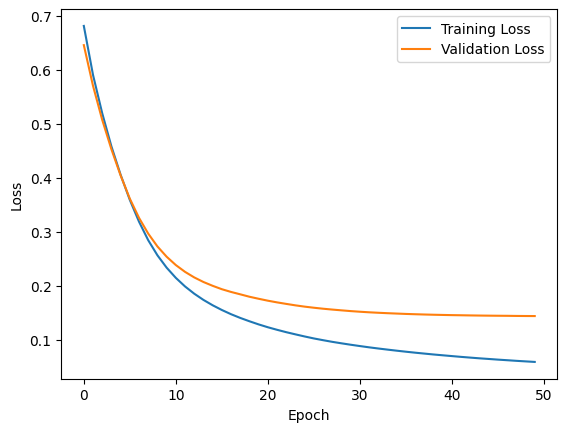

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9649 - loss: 0.0661
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9890 - loss: 0.0583
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9560 - loss: 0.1440
Train Accuracy: 0.9890 | Train Loss: 0.0583
Validation Accuracy: 0.9560 | Validation Loss: 0.1440
Test Accuracy: 0.9649 | Test Loss: 0.0661
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[1 0 0 1 1 0 0 0 0 1]]


In [1]:
import numpy as np
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

##########################################################################
# 1. Load, observe and analyze the data:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target  # Features and labels

##########################################################################
# 2. Preprocess and clean the data:
# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize the features to improve training stability
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

##########################################################################
# 3. Define the MLP model using Keras
# 3a.  Define the model architecture (type of the model, number of layers, activation functions)
model = keras.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),  # Input Layer
    layers.Dense(30, activation='relu'),  # First hidden layer
    layers.Dense(15, activation='relu'),  # Second hidden layer
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

#3b. Set model hyperparameters (Appropriate loss function, optimizer and its parameters, evaluation metrics)
#model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
##########################################################################
# 4. Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val))

# Plot history:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

##########################################################################
# 5. Evaluate the model and make predictions
# 5a. Evaluate the model on the train, validation and test sets
test_loss, test_acc = model.evaluate(X_test, y_test)
train_loss, train_acc = model.evaluate(X_train, y_train)
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# 5b. Make predictions
predictions = (model.predict(X_test) > 0.5).astype(int)
print(predictions[:10].T)

### Keras backend
- by default Tensorflow, but we can change it:

In [ ]:
from keras import backend

print(f"Current backend: {backend.backend()}")

Current backend: tensorflow


In [ ]:
# restart kernel before running this code!
import os
os.environ["KERAS_BACKEND"] = "torch"  # "tensorflow" "jax", "torch"
from keras import backend

print(f"Current backend: {backend.backend()}")


Current backend: tensorflow


## Define and train the same model in Tensorflow

- Compared to Keras, the low-level TensorFlow API requires a more explicit implementation of the training process.

- Main differences from Keras:

  - The **training loop is written manually**
  - Gradients are computed using **`tf.GradientTape()`**, which records operations and enables automatic differentiation.
  - Model parameters (weights and biases) are often defined explicitly as **TensorFlow variables**.
  - Parameter updates are performed manually using an **optimizer**.
  - This style offers more flexibility but requires more code than Keras.

This approach provides more control over the training process but is more verbose than using the high-level Keras API.


Epoch 1/50 | Train loss: 5.7112 | Val loss: 6.1823
Epoch 2/50 | Train loss: 5.5866 | Val loss: 6.1336
Epoch 3/50 | Train loss: 5.5125 | Val loss: 5.9143
Epoch 4/50 | Train loss: 4.9484 | Val loss: 3.6788
Epoch 5/50 | Train loss: 2.0472 | Val loss: 0.8370
Epoch 6/50 | Train loss: 0.9160 | Val loss: 0.7889
Epoch 7/50 | Train loss: 0.6988 | Val loss: 0.7300
Epoch 8/50 | Train loss: 0.5662 | Val loss: 0.6478
Epoch 9/50 | Train loss: 0.4909 | Val loss: 0.5891
Epoch 10/50 | Train loss: 0.4546 | Val loss: 0.5535
Epoch 11/50 | Train loss: 0.4213 | Val loss: 0.5074
Epoch 12/50 | Train loss: 0.3841 | Val loss: 0.4801
Epoch 13/50 | Train loss: 0.3369 | Val loss: 0.4554
Epoch 14/50 | Train loss: 0.2997 | Val loss: 0.4296
Epoch 15/50 | Train loss: 0.2808 | Val loss: 0.4105
Epoch 16/50 | Train loss: 0.2564 | Val loss: 0.3946
Epoch 17/50 | Train loss: 0.2400 | Val loss: 0.3810
Epoch 18/50 | Train loss: 0.2280 | Val loss: 0.3680
Epoch 19/50 | Train loss: 0.2201 | Val loss: 0.3555
Epoch 20/50 | Train l

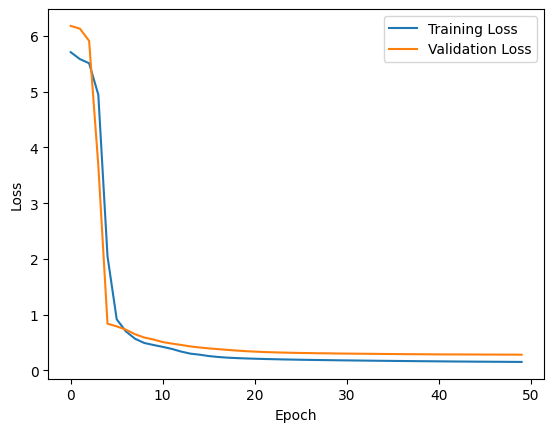

Train Accuracy: 0.9753 | Train Loss: 0.1464
Validation Accuracy: 0.9341 | Validation Loss: 0.2804
Test Accuracy: 0.9298 | Test Loss: 0.2094
Sample Predictions: [1 0 0 1 1 0 0 0 1 1]


In [35]:
##########################################################################
# 1. Load, observe and analyze the data:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target  # Features and labels

##########################################################################
# 2. Preprocess and clean the data:
# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize the features to improve training stability
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)


##########################################################################
# 3. Define the MLP model using pure Tensorflow
import tensorflow as tf
class MLPModel(tf.Module):
    def __init__(self): # Initialize weights and biases for each layer
        super().__init__()
        self.w1 = tf.Variable(tf.random.normal([X_train.shape[1], 30]), dtype=tf.float32)
        self.b1 = tf.Variable(tf.zeros([30]), dtype=tf.float32)
        self.w2 = tf.Variable(tf.random.normal([30, 15]), dtype=tf.float32)
        self.b2 = tf.Variable(tf.zeros([15]), dtype=tf.float32)
        self.w3 = tf.Variable(tf.random.normal([15, 1]), dtype=tf.float32)
        self.b3 = tf.Variable(tf.zeros([1]), dtype=tf.float32)

    def __call__(self, x): # Forward pass through the network
        x = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        x = tf.nn.relu(tf.matmul(x, self.w2) + self.b2)
        x = tf.nn.sigmoid(tf.matmul(x, self.w3) + self.b3)
        return x

# Initialize the model
model = MLPModel()

# Define the loss function and optimizer
loss_fn = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

##########################################################################
# 4. Train the model
epochs = 50
batch_size = 16
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

def train_step(model, x, y):
    with tf.GradientTape() as tape:
        predictions = model(x)                    # forward pass
        loss = loss_fn(y[:, None], predictions)   # compute the loss
    # backward pass: Compute gradients of the loss with respect to model parameters
    gradients = tape.gradient(loss, [model.w1, model.b1, model.w2, model.b2, model.w3, model.b3])
    # update weights
    optimizer.apply_gradients(zip(gradients, [model.w1, model.b1, model.w2, model.b2, model.w3, model.b3]))
    return loss

train_losses = []
val_losses = []

# Train the model for the specified number of epochs
for epoch in range(epochs):
    epoch_loss = 0

    for x_batch, y_batch in train_dataset:
        train_loss = train_step(model, x_batch, y_batch)
        epoch_loss += train_loss.numpy() * x_batch.shape[0]
    epoch_loss /= X_train.shape[0]

    # validation loss:
    val_preds = model(X_val)
    val_loss = loss_fn(y_val, val_preds).numpy()
    print(f"Epoch {epoch+1}/{epochs} | Train loss: {epoch_loss:.4f} | Val loss: {val_loss:.4f}")
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

# Plot history:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##########################################################################
# 5. Evaluate the model and make predictions
# 5a. Evaluate the model on the train, validation and test sets
def compute_loss_and_accuracy(model, X, y):
    predictions = model(X)
    loss = loss_fn(y[:, None], predictions).numpy()
    accuracy = np.mean((predictions.numpy().flatten() > 0.5).astype(int) == y)
    return loss, accuracy

train_loss, train_acc = compute_loss_and_accuracy(model, X_train, y_train)
val_loss, val_acc = compute_loss_and_accuracy(model, X_val, y_val)
test_loss, test_acc = compute_loss_and_accuracy(model, X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# 5b. Make predictions
predictions = (model(X_test).numpy().flatten() > 0.5).astype(int)
print("Sample Predictions:", predictions[:10])

### GradientTape in Tensorflow
- tensor in Tensorflow (tf.Tensor) is a multi-dimensional array similar to a NumPy array but optimized for GPU/TPU computation
- A trainable tensor (tf.Variable) is an enhanced version of a tensor that allows modification and gradient tracking during training
- tf.GradientTape() allows automatic symbolic differentiation:
    - It builds a computational graph, recording elementary operations
    - During the backward pass, it traverses the graph in reverse and computes exact symbolic derivatives using the chain rule.

In [14]:
import tensorflow as tf
import numpy as np

# Define a simple function: f(x) = x^2 + 3x + 5
def f(x):
    return x**2 + 3*x + 5

# Define input tensor
x = tf.Variable(2.0)  # Start with x = 2.0
# x = tf.Variable(np.array([-1, 0, 1, 2], dtype=np.float32))
# x = tf.Variable(np.array([[2, 1], [5, 0]], dtype=np.float32))

# Compute the derivative using GradientTape
with tf.GradientTape() as tape:
    y = f(x)  # Compute function value

# Compute df/dx ... backward pass
dy_dx = tape.gradient(y, x)

# Print the result
print(f"Function value at x=2: f(2) = {y.numpy()}")
print(f"Derivative at x=2: f'(2) = {dy_dx.numpy()}")  # Should be 2(2) + 3 = 7

Function value at x=2: f(2) = 15.0
Derivative at x=2: f'(2) = 7.0


## Define and train the model in PyTorch:
- Compared to Keras, PyTorch provides a **lower-level interface** and gives the programmer more control over the training process.

- Main differences from Keras:

  - The **training loop must be written manually** (forward pass, loss computation, backward pass, optimizer step).
  - Gradients are computed using **automatic differentiation** with `loss.backward()`.
  - Model parameters are updated explicitly using an **optimizer** (`optimizer.step()`).
  - The model architecture is typically defined as a **Python class** inheriting from `nn.Module`.
  - This style offers more flexibility but requires more code than Keras.

PyTorch is widely used in **research and experimental projects** due to its flexibility and Python-like programming style.


Epoch 1/50 | Train loss: 0.6534 | Val loss: 0.6411
Epoch 2/50 | Train loss: 0.6338 | Val loss: 0.6221
Epoch 3/50 | Train loss: 0.6135 | Val loss: 0.6020
Epoch 4/50 | Train loss: 0.5921 | Val loss: 0.5803
Epoch 5/50 | Train loss: 0.5692 | Val loss: 0.5566
Epoch 6/50 | Train loss: 0.5446 | Val loss: 0.5314
Epoch 7/50 | Train loss: 0.5188 | Val loss: 0.5049
Epoch 8/50 | Train loss: 0.4919 | Val loss: 0.4778
Epoch 9/50 | Train loss: 0.4648 | Val loss: 0.4508
Epoch 10/50 | Train loss: 0.4381 | Val loss: 0.4246
Epoch 11/50 | Train loss: 0.4120 | Val loss: 0.3994
Epoch 12/50 | Train loss: 0.3867 | Val loss: 0.3753
Epoch 13/50 | Train loss: 0.3623 | Val loss: 0.3523
Epoch 14/50 | Train loss: 0.3388 | Val loss: 0.3308
Epoch 15/50 | Train loss: 0.3162 | Val loss: 0.3103
Epoch 16/50 | Train loss: 0.2947 | Val loss: 0.2912
Epoch 17/50 | Train loss: 0.2744 | Val loss: 0.2735
Epoch 18/50 | Train loss: 0.2553 | Val loss: 0.2574
Epoch 19/50 | Train loss: 0.2376 | Val loss: 0.2425
Epoch 20/50 | Train l

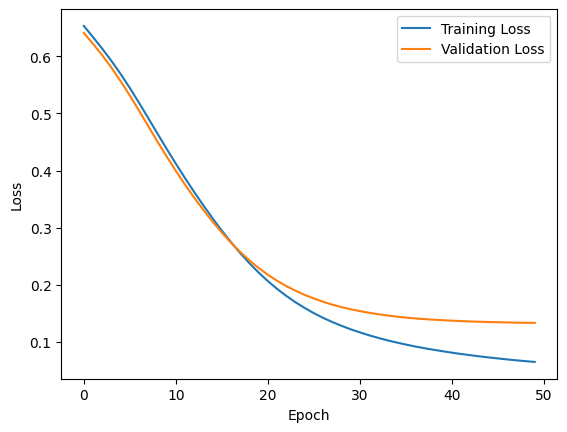

Train Accuracy: 0.9863 | Train Loss: 0.0637
Validation Accuracy: 0.9560 | Validation Loss: 0.1331
Test Accuracy: 0.9737 | Test Loss: 0.0755
tensor([[1, 0, 0, 1, 1, 0, 0, 0, 1, 1]], dtype=torch.int32)


In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

##########################################################################
# 1. Load, observe and analyze the data:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target  # Features and labels

##########################################################################
# 2. Preprocess and clean the data:
# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize the features to improve training stability
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# Convert data to PyTorch tensors
# PyTorch models operate on tensors instead of NumPy arrays
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

##########################################################################
# 3. Define the MLP model using pure PyTorch
# In PyTorch we define a model as a class inheriting from nn.Module

class MLP(nn.Module):
    def __init__(self, input_size): # Initialize weights and biases for each layer
        super().__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, 30)
        self.fc2 = nn.Linear(30, 15)
        self.fc3 = nn.Linear(15, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x): # Define the forward pass of the network
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Create model instance
model = MLP(X_train.shape[1])

##########################################################################
# 3b. Set model hyperparameters

# Define loss function and optimizer
loss_function = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = optim.SGD(model.parameters(), lr=0.01)

##########################################################################
# 4. Train the model
epochs = 50
batch_size = 16

train_losses = []
val_losses = []

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size)

def train(model, optimizer, loss_function, train_loader, val_loader, epochs):

      # Training loop (explicit in PyTorch)
    for epoch in range(epochs):
          model.train()  # set model to training mode
          epoch_loss = 0
          for X_batch, y_batch in train_loader:
              optimizer.zero_grad()
              outputs = model(X_batch)               # forward pass
              loss = loss_function(outputs, y_batch) # compute the loss
              loss.backward()                        # backward pass (compute gradients)
              optimizer.step()                       # update weights
              epoch_loss += loss.item() * X_batch.size(0)
          epoch_loss /= len(train_loader.dataset)

          # Validation loss
          model.eval()
          with torch.no_grad():
              val_outputs = model(X_val)
              val_loss = loss_function(val_outputs, y_val)

          train_losses.append(epoch_loss)
          val_losses.append(val_loss.item())

          print(f"Epoch {epoch+1}/{epochs} | Train loss: {epoch_loss:.4f} | Val loss: {val_loss:.4f}")
    return train_losses, val_losses

train_losses, val_losses = train(model, optimizer, loss_function, train_loader, val_loader, epochs)

##########################################################################
# Plot history

import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

##########################################################################
# 5. Evaluate the model and make predictions
def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        y_pred = model(X)
        loss = loss_function(y_pred, y).item()
        accuracy = ((y_pred > 0.5).float() == y).float().mean().item()
    return loss, accuracy

train_loss, train_acc = evaluate(model, X_train, y_train)
val_loss, val_acc = evaluate(model, X_val, y_val)
test_loss, test_acc = evaluate(model, X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

##########################################################################
# 5b. Make predictions
with torch.no_grad():
    predictions = (model(X_test) > 0.5).int()

print(predictions[:10].T)


### **Autograd in PyTorch**
- A **tensor (`torch.Tensor`)** in PyTorch is a multi-dimensional array similar to a NumPy array but optimized for GPU/TPU computation.
- A **trainable tensor (`torch.nn.Parameter`)** is an enhanced version of a tensor that allows modifications and gradient tracking during training.
- **`torch.autograd` enables automatic differentiation**:
    - It dynamically builds a computational graph, recording operations on tensors with `requires_grad=True`.
    - During the **backward pass**, it traverses the graph in reverse and computes **exact symbolic derivatives** using the **chain rule**.
- **Differences from TensorFlow**:
    - PyTorch builds the computational graph dynamically (eager execution), while TensorFlow supports both eager and static graph modes.
    - In PyTorch, gradients accumulate by default and must be manually reset using `optimizer.zero_grad()`, whereas in TensorFlow, `tf.GradientTape()` clears gradients automatically unless `persistent=True` is set.


In [30]:
import torch

# Define a simple function: f(x) = x^2 + 3x + 5
def f(x):
    return x**2 + 3*x + 5

# Define input tensor – uncomment one of the following:
x = torch.tensor(2.0, requires_grad=True)  # Scalar
#x = torch.tensor([-1, 0, 1, 2], dtype=torch.float32, requires_grad=True)  # Vector
#x = torch.tensor([[2, 1], [5, 0]], dtype=torch.float32, requires_grad=True)  # Matrix

# Compute function value
y = f(x)

# Compute df/dx ... backward pass
# For scalar output: use backward() directly
# For non-scalar output: provide gradient of same shape
if y.numel() == 1:
    y.backward()
else:
    y.backward(torch.ones_like(y))

# Print results
print(f"Function value f(x):\n{y.detach().numpy()}")
print(f"Derivative f'(x):\n{x.grad.numpy()}")

Function value f(x):
15.0
Derivative f'(x):
7.0


## Define and train the model in PyTorch Lightning
- PyTorch Lightning removes the repetitive boilerpate code, making the implementation shorter and cleaner.
- Model definition (`layers`,  `forward()`, `loss`) remains the same
- The manual training loop is replaced by the high-level `Trainer` object:
    - you define logic in `training_step()` and `validation_step()` methods.
    - No manual for-loops — training runs via `trainer.fit(model, train_loader, val_loader)`
- It includes a callback and checkpoint system for:
   - automatic model saving (ModelCheckpoint)
   - early stopping (EarlyStopping)
   - logging and progress monitoring

In [31]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.8 MB/s eta 0:00:00


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import numpy as np

##########################################################################
# 1. Load, observe and analyze the data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target


##########################################################################
# 2. Preprocess and clean the data:
# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)

# Convert to PyTorch tensors
X_train, X_test, X_val = map(torch.tensor, (X_train, X_test, X_val))
y_train, y_test, y_val = map(lambda y: torch.tensor(y, dtype=torch.float32).view(-1, 1), (y_train, y_test, y_val))

# Create DataLoaders
batch_size = 16
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

##########################################################################
# 3. Define the MLP model using PyTorch Lightning
class MLP(pl.LightningModule):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 30)
        self.fc2 = nn.Linear(30, 15)
        self.fc3 = nn.Linear(15, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.loss_fn = nn.BCELoss()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)                                 # forward pass
        loss = self.loss_fn(y_pred, y)                   # compute the loss
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        return optim.SGD(self.parameters(), lr=0.01)

# Initialize model
model = MLP(input_dim=X_train.shape[1])

# 4. Train the model using PyTorch Lightning Trainer
epochs = 50
trainer = pl.Trainer(max_epochs=epochs, log_every_n_steps=10)
trainer.fit(model, train_loader, val_loader)

# 5. Evaluate the model
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for x, y in dataloader:
            y_pred = model(x)
            loss = model.loss_fn(y_pred, y).item()
            correct += ((y_pred > 0.5).float() == y).sum().item()
            total_loss += loss
    accuracy = correct / len(dataloader.dataset)
    return total_loss / len(dataloader), accuracy

train_loss, train_acc = evaluate(model, train_loader)
val_loss, val_acc = evaluate(model, val_loader)
test_loss, test_acc = evaluate(model, test_loader)

print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# 5b. Make predictions
y_pred = (model(X_test) > 0.5).float()
print("Sample Predictions:", y_pred[:10].T.numpy())

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ fc1     │ Linear  │    930 │ train │     0 │
│ 1 │ fc2     │ Linear  │    465 │ train │     0 │
│ 2 │ fc3     │ Linear  │     16 │ train │     0 │
│ 3 │ relu    │ ReLU    │      0 │ train │     0 │
│ 4 │ sigmoid │ Sigmoid │      0 │ train │     0 │
│ 5 │ loss_fn │ BCELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 1.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Train Accuracy: 0.9780 | Train Loss: 0.0790
Validation Accuracy: 0.9560 | Validation Loss: 0.1485
Test Accuracy: 0.9737 | Test Loss: 0.1028
Sample Predictions: [[1. 0. 0. 1. 1. 0. 0. 0. 0. 1.]]


## Define and train the model in Jax (with Flax and Optax)

- JAX follows a different programming paradigm compared to Keras and PyTorch.

Main differences from Keras:

- JAX uses a **functional programming style** instead of object-oriented models.
- Gradients are computed explicitly using **`jax.grad()`**.
- Training is implemented through **pure functions** that transform model parameters.
- Computations can be **compiled and accelerated using `jax.jit()`**.
- Models are usually defined using libraries such as **Flax or Haiku**.

JAX is often used in **research and high-performance computing**, especially when very efficient numerical computations are required.


Epoch 1/50 | Train loss: 0.6647 | Val loss: 0.6703
Epoch 2/50 | Train loss: 0.6589 | Val loss: 0.6655
Epoch 3/50 | Train loss: 0.6532 | Val loss: 0.6608
Epoch 4/50 | Train loss: 0.6475 | Val loss: 0.6559
Epoch 5/50 | Train loss: 0.6418 | Val loss: 0.6508
Epoch 6/50 | Train loss: 0.6361 | Val loss: 0.6457
Epoch 7/50 | Train loss: 0.6304 | Val loss: 0.6404
Epoch 8/50 | Train loss: 0.6246 | Val loss: 0.6351
Epoch 9/50 | Train loss: 0.6189 | Val loss: 0.6297
Epoch 10/50 | Train loss: 0.6134 | Val loss: 0.6243
Epoch 11/50 | Train loss: 0.6078 | Val loss: 0.6188
Epoch 12/50 | Train loss: 0.6024 | Val loss: 0.6133
Epoch 13/50 | Train loss: 0.5970 | Val loss: 0.6080
Epoch 14/50 | Train loss: 0.5917 | Val loss: 0.6028
Epoch 15/50 | Train loss: 0.5866 | Val loss: 0.5977
Epoch 16/50 | Train loss: 0.5816 | Val loss: 0.5927
Epoch 17/50 | Train loss: 0.5766 | Val loss: 0.5878
Epoch 18/50 | Train loss: 0.5719 | Val loss: 0.5832
Epoch 19/50 | Train loss: 0.5673 | Val loss: 0.5788
Epoch 20/50 | Train l

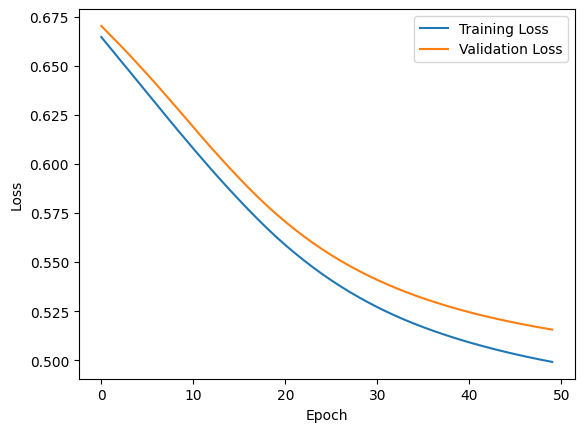

Train Accuracy: 0.9670 | Train Loss: 0.4987
Validation Accuracy: 0.9341 | Validation Loss: 0.5156
Test Accuracy: 0.9649 | Test Loss: 0.5013
[[1 0 0 1 1 0 0 0 0 1]]


In [37]:
import numpy as np
import jax
import jax.numpy as jnp
import optax
from flax import linen as nn
from flax.training import train_state

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

##########################################################################
# 1. Load, observe and analyze the data:

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target  # Features and labels

##########################################################################
# 2. Preprocess and clean the data:

# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize the features to improve training stability
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# Convert data to JAX arrays
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
X_val = jnp.array(X_val)

y_train = jnp.array(y_train).reshape(-1,1)
y_test = jnp.array(y_test).reshape(-1,1)
y_val = jnp.array(y_val).reshape(-1,1)

##########################################################################
# 3. Define the MLP model using Flax (JAX)

# In JAX/Flax we define models as classes inheriting from nn.Module
class MLP(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(30)(x)
        x = nn.relu(x)
        x = nn.Dense(15)(x)
        x = nn.relu(x)
        x = nn.Dense(1)(x)
        x = nn.sigmoid(x)
        return x

# Initialize the model
model = MLP()

rng = jax.random.PRNGKey(0)
params = model.init(rng, X_train)

##########################################################################
# 3b. Set model hyperparameters

# Binary cross entropy loss
def loss_fn(params, X, y):
    preds = model.apply(params, X)
    loss = optax.sigmoid_binary_cross_entropy(preds, y).mean()
    return loss

# Define optimizer
optimizer = optax.sgd(learning_rate=0.01)

state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=params,
    tx=optimizer
)

##########################################################################
# 4. Train the model

epochs = 50
batch_size = 16

train_losses = []
val_losses = []

# Training step
@jax.jit
def train_step(state, X, y):

    def loss_wrapper(params):
        preds = state.apply_fn(params, X)
        loss = optax.sigmoid_binary_cross_entropy(preds, y).mean()
        return loss

    grads = jax.grad(loss_wrapper)(state.params)
    state = state.apply_gradients(grads=grads)

    loss = loss_wrapper(state.params)

    return state, loss

# Evaluation step
@jax.jit
def eval_step(params, X, y):

    preds = model.apply(params, X)
    loss = optax.sigmoid_binary_cross_entropy(preds, y).mean()

    return loss


for epoch in range(epochs):

    permutation = np.random.permutation(len(X_train))

    epoch_loss = 0

    for i in range(0, len(X_train), batch_size):

        idx = permutation[i:i+batch_size]

        batch_X = X_train[idx]
        batch_y = y_train[idx]

        state, loss = train_step(state, batch_X, batch_y)

        epoch_loss += float(loss) * len(idx)

    epoch_loss /= len(X_train)

    # Validation loss
    val_loss = eval_step(state.params, X_val, y_val)

    train_losses.append(epoch_loss)
    val_losses.append(float(val_loss))

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {epoch_loss:.4f} | Val loss: {val_loss:.4f}")

##########################################################################
# Plot history

import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##########################################################################
# 5. Evaluate the model and make predictions

def accuracy(params, X, y):
    preds = model.apply(params, X)
    preds = (preds > 0.5).astype(jnp.int32)
    return (preds == y).mean()

train_loss = eval_step(state.params, X_train, y_train)
val_loss = eval_step(state.params, X_val, y_val)
test_loss = eval_step(state.params, X_test, y_test)

train_acc = accuracy(state.params, X_train, y_train)
val_acc = accuracy(state.params, X_val, y_val)
test_acc = accuracy(state.params, X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

##########################################################################
# 5b. Make predictions

predictions = (model.apply(state.params, X_test) > 0.5).astype(int)
print(predictions[:10].T)


# **Do the environments use GPU implicitly?**
- **TensorFlow/Keras** - Yes, if a GPU is available, it is used automatically.  
- **JAX** – Yes, computations automatically run on the available accelerator (GPU/TPU) if the appropriate backend is installed.
- **PyTorch** - No, it defaults to CPU unless explicitly moved to GPU (`model.to("cuda")`).  
- **PyTorch Lightning** - Yes, but only if `accelerator="gpu"` is set in the `Trainer`. Otherwise, it defaults to CPU.  



In [ ]:
# Tensorflow:
import tensorflow as tf
print("Is TensorFlow using GPU?", tf.config.list_physical_devices('GPU'))

#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Force CPU (optional)

Is TensorFlow using GPU? [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
# Jax:
import jax
print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

# import os
#os.environ["JAX_PLATFORM_NAME"] = "cpu"  # Force CPU (optional)


JAX devices: [CudaDevice(id=0)]
Default backend: gpu


In [ ]:
# Pytorch:
import torch
print("Is CUDA available?", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X_train, y_train = X_train.to(device), y_train.to(device)

Is CUDA available? True


In [ ]:
# Lightning:
trainer = pl.Trainer(accelerator="gpu", devices=1)  # TO GPU
#trainer = pl.Trainer(accelerator="cpu")

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


### **Using GPU in Google Colab**
By default, Google Colab runs on a CPU. To enable GPU acceleration:

1. **Go to:** `Runtime` → `Change runtime type`
2. **Select:** `Hardware accelerator` → `GPU`
3. **Click:** `Save`

To verify that a GPU is available in PyTorch or TensorFlow, run:


In [ ]:
import torch
print("Is GPU available?", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

Is GPU available? True
GPU name: Tesla T4


In [ ]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
  print("GPU is available and being used by TensorFlow")
else:
  print("GPU is not available or not being used by TensorFlow")

GPU is available and being used by TensorFlow


# Current versions of packages:

In [33]:
import tensorflow as tf
import keras
import torch
import jax

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"JAX version: {jax.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.13.2
PyTorch version: 2.10.0+cpu
JAX version: 0.7.2
